# CLABTOOLKIT — Practical Examples

> **Package:** `clabtoolkit` · **Authors:** Yasser Alemán-Gómez, Nino Herve · **Version:** latest

---

## Overview

This notebook provides a curated set of hands-on examples covering the main modules of **CLABTOOLKIT**, an open-source Python toolkit for neuroimaging research. The examples are organized around three broad themes:

1. **Core objects** — Working with the fundamental data structures of the toolkit: `Parcellation`, `Surface`, `Tractogram`, and `Connectome`. You will learn how to load and inspect these objects, manipulate their content, extract region-wise metrics, and derive structural/functional connectomes.

2. **Morphometry** — Parsing FreeSurfer cortical statistics outputs and computing region-level morphometric values (e.g. cortical thickness, surface area, volume) directly from annotation files.

3. **Visualization** — Plotting neuroimaging objects and building rich 3-D scenes using the PyVista-based visualization layer of CLABTOOLKIT.

Each section is self-contained and can be run independently, provided the required input files and dependencies are available. Code cells marked with `# TODO` are placeholders where example code will be added.

---

### Table of Contents

---

* 🔷 1. [`Core Objects`](#parcellation-morphometry)
    * 🔸 1.1. [`Parcellation`](#parcellation-class)
        * 🔸 1.1.1. [`Loading Parcellation`](#parcellation-loading)
            * 🔹 1.1.1.a. [`load`](#parcellation-load). Initialize the Parcellation class with a parcellation file or array
            * 🔹 1.1.1.b. [`get_info`](#parcellation-get_info). Display and return comprehensive information about the Parcellation object
        * 🔸 1.1.2. [`Parcellation Manipulation`](#parcellation-manipulation)
            * 🔹 1.1.2.a. [`keep_by_name`](#parcellation-keep_by_name). Filter the parcellation by region names
            * 🔹 1.1.2.b. [`remove_by_name`](#parcellation-remove_by_name). Filter the parcellation by region codes
            * 🔹 1.1.2.c. [`add_parcellation`](#parcellation-add_parcellation). Combine another parcellation with this one
            * 🔹 1.1.2.d. [`save_parcellation`](#parcellation-save_parcellation). Save the parcellation to a file
        * 🔸 1.1.3. [`Extract Metrics`](#parcellation-metrics)
            * 🔹 1.1.3.a. [`compute_volume_table`](#parcellation-compute_volume_table). Calculate volumes for each region
            * 🔹 1.1.3.b. [`get_regionwise_timeseries`](#parcellation-get_regionwise_timeseries). Compute region-wise time series
        * 🔸 1.1.4. [`Compute Connectivity`](#parcellation-connectivity)
            * 🔹 1.1.4.a. [`compute_functional_connectome`](#parcellation-compute_functional_connectome). Compute a functional connectivity (FC) matrix from a ROI × time series or 4-D NIfTI file
            * 🔹 1.1.4.b. [`compute_structural_connectome`](#parcellation-compute_structural_connectome). Compute a structural connectivity matrix from a tractogram
    * 🔸 1.2. [`Surface`](#surface-class)
        * 🔸 1.2.1. [`load_scalar_map`](#surface-load_scalar_map). Load a scalar map onto the surface
        * 🔸 1.2.2. [`load_annotation`](#surface-load_annotation). Load a surface annotation file
        * 🔸 1.2.3. [`map_volume_to_surface`](#surface-map_volume_to_surface). Map a volumetric image onto the surface
    * 🔸 1.3. [`Tractogram`](#tractogram-class)
        * 🔸 1.3.1. [`compute_centroids`](#tractogram-compute_centroids). Compute the centroid streamline for each bundle
        * 🔸 1.3.2. [`interpolate_on_tractogram`](#tractogram-interpolate_on_tractogram). Interpolate scalar values along streamlines
        * 🔸 1.3.3. [`filter_streamlines`](#tractogram-filter_streamlines). Filter streamlines by length, ROI, or label
    * 🔸 1.4. [`Connectome`](#connectome-class)
        * 🔸 1.4.1. [`get_connectivity_stats`](#connectome-get_connectivity_stats). Compute summary statistics from the connectivity matrix
        * 🔸 1.4.2. [`plot_matrix`](#connectome-plot_matrix). Render the connectivity matrix as a heatmap

* 🔷 2. [`Morphometry`](#morpho-morphometry)
    * 🔸 2.1. [`Parse FreeSurfer Outputs`](#morpho-freesmorpho)
        * 🔸 2.1.1. [`parse_freesurfer_cortex_stats`](#morpho-parse_freesurfer_cortex_stats). Parse FreeSurfer cortical statistics files
    * 🔸 2.2. [`Object-Based Morphometry`](#parcellation-obasedmorpho)
        * 🔸 2.2.1. [`compute_reg_val_fromannot`](#morpho-compute_reg_val_fromannot). Compute region-wise values from an annotation file

* 🔷 3. [`Visualization`](#parcellation-visualization)
    * 🔸 3.1. [`Plotting Objects`](#parcellation-pobjects). Configure and render individual brain objects
    * 🔸 3.2. [`Plotting Scene`](#parcellation-pscene). Compose and export multi-object brain scenes

---

---
<a id="parcellation-morphometry"></a>

* **🔷 1. [`Core Objects`](#parcellation-morphometry)**: Working with the fundamental data structures of the toolkit

---
<a id="parcellation-class"></a>

* **🔸 1.1. [`Parcellation`](#parcellation-class)**: Class for analysing and manipulating brain parcellations

---
<a id="parcellation-loading"></a>

* **🔸 1.1.1. [`Loading Parcellation`](#parcellation-loading)**: Load a parcellation from a file or array

<a id="parcellation-load"></a>

* 🔹 1.1.1.a. **`load`**: Initialize the Parcellation class with a parcellation file or array

---

In [4]:
########################### Testing Parcellation Class ###########################
import clabtoolkit.parcellationtools as cltparc
import clabtoolkit.misctools as cltmisc
import os


fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

print("Test 1: Creating a Parcellation Object from file without color table...")
print("Allowed formats: .nii, .nii.gz, .mgz, .img, .mnc")
print("NOTE: Region names, colors and opacities will be default values.")

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file)
print("-------------------------------")
print(" ")

Test 1: Creating a Parcellation Object from file without color table...
Allowed formats: .nii, .nii.gz, .mgz, .img, .mnc
NOTE: Region names, colors and opacities will be default values.
-------------------------------
 


<a id="parcellation-get_info"></a>

* 🔹 1.1.1.b. **`get_info`**: Display and return comprehensive information about the Parcellation object

---

In [ ]:
########################### Testing get_info ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

# Loading the parcellation with color table
print("Test 1: Getting parcellation information for a Parcellation Object and printing the table...")
parc = cltparc.Parcellation(parc_file, color_table=lut_file)
info = parc.get_info()
print(" ")


print("Test 2: Getting parcellation information for a Parcellation Object and looking at the dictionary...")
info = parc.get_info(verbose=False)
print("\nParcellation Information:")
print(f"  ID          : {info['id']}")
print(f"  Space       : {info['space']}")
print(f"  Parcellation : {info['parc_file']}")
print(f"  Dimensions   : {info['dim']}")
print(f"  Voxel size   : {info['voxel_size']}")
print(f"  Voxel volume : {info['voxel_volume']}")
print(f"  Data type    : {info['dtype']}")
print(f"  Affine       :\n{info['affine']}")
print("-------------------------------")
print(" ")

Test 1: Creating a Parcellation Object from file with color table...
Allowed formats: .nii, .nii.gz, .mgz, .img, .mnc
NOTE: Region names, colors and opacities will be default values.
╔════════════════════════════════════════════════════════════════╗
║                        PARCELLATION INFO                       ║
╠════════════════════════════════════════════════════════════════╣
║  ID     : aparc+aseg                                           ║
║  Space  : unknown                                              ║
║  File   : /opt/freesurfer/subjects/bert/mri/aparc+aseg.mgz     ║
╠════════════════════════════════════════════════════════════════╣
║  IMAGE PROPERTIES                                              ║
║    Dimensions  :      256 x 256 x 256                          ║
║    Voxel size  :      1.0 x 1.0 x 1.0 mm                       ║
║    Voxel volume:            1.000 mm³                          ║
║    Data type   :                  >i4                          ║
╠════════════

<a id="parcellation-manipulation"></a>

* **🔸 1.1.2. [`Parcellation Manipulation`](#parcellation-manipulation)**: Methods to filter, combine and save parcellations

---
<a id="parcellation-keep_by_name"></a>

* 🔹 1.1.2.a. **`keep_by_name`**: Filter the parcellation keeping only the specified region names

---

In [ ]:
########################### Testing keep_by_name ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)  


print("Test 1: Keeping regions by their names...")
print("Original number of regions:", len(parc.name))

regions_to_keep = ['ctx-rh-precentral', 'ctx-lh-precentral', 'ctx-rh-postcentral', 'ctx-lh-postcentral']
parc.keep_by_name(regions_to_keep)

print("Number of regions after keep_by_name:", len(parc.name))
print("Remaining region names:", parc.name)
print("Remaining region codes:", parc.index)
print("-------------------------------")
print(" ")

print("Test 2: Keeping regions by names and rearranging the values to be consecutive...")
parc = cltparc.Parcellation(parc_file, color_table=lut_file)  
print("Original number of regions:", len(parc.name))

regions_to_keep = ['ctx-rh-precentral', 'ctx-lh-precentral', 'ctx-rh-postcentral', 'ctx-lh-postcentral']
parc.keep_by_name(regions_to_keep, rearrange=True)
print("Number of regions after keep_by_name:", len(parc.name))
print("Remaining region names:", parc.name)
print("Remaining region codes:", parc.index)
print("-------------------------------")
print(" ")

<a id="parcellation-remove_by_name"></a>

* 🔹 1.1.2.b. **`remove_by_name`**: Filter the parcellation by removing the specified region names

---

In [ ]:
########################### Testing remove_by_name ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)  

print("Test 1: Removing all the regions with ctx- on their names...")
print("Original number of regions:", len(parc.name))
regions_to_remove = ['ctx-']
parc.remove_by_name(regions_to_remove)
print("Number of regions after remove_by_name:", len(parc.name))
print("Remaining region names:", parc.name)
print("Remaining region codes:", parc.index)
print("-------------------------------")
print(" ")

parc = cltparc.Parcellation(parc_file, color_table=lut_file)  
print("Test 2: Removing regions by names and rearranging the values to be consecutive...")
print("Original number of regions:", len(parc.name))
regions_to_remove = ['ctx-']
parc.remove_by_name(regions_to_remove, rearrange=True)
print("Number of regions after remove_by_name:", len(parc.name))
print("Remaining region names:", parc.name)
print("Remaining region codes:", parc.index)
print("-------------------------------")
print(" ")


<a id="parcellation-add_parcellation"></a>

* 🔹 1.1.2.c. **`add_parcellation`**: Combine another parcellation with this one

---

In [ ]:
########################### Testing add_parcellation ###########################
import clabtoolkit.parcellationtools as cltparc

import os
import copy

fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)
parc_tmp_ctx_rh = copy.deepcopy(parc)

# Keeping the Right cortical regions 
parc_tmp_ctx_rh.keep_by_name(['ctx-rh-'])

# Keeping the Left Thalamus, Left Caudate, Left Putamen, Left Pallidum
parc_tmp_subc = copy.deepcopy(parc)
parc_tmp_subc.keep_by_code([10, 11, 12, 13])

print('Test 1: Adding two parcellations together...')
print("1. Number of regions before adding parcellation:", len(parc_tmp_ctx_rh.name))

parc_tmp_ctx_rh.add_parcellation(parc_tmp_subc)
print("2. Number of regions after adding two parcellations:", len(parc_tmp_ctx_rh.name))
print("-------------------------------")

Test 1: Keeping regions by their names...
Original number of regions: 110
Number of regions after keep_by_name: 4
Remaining region names: ['ctx-lh-postcentral', 'ctx-lh-precentral', 'ctx-rh-postcentral', 'ctx-rh-precentral']
Remaining region codes: [1022, 1024, 2022, 2024]
-------------------------------
 
Test 2: Keeping regions by names and rearranging the values to be consecutive...
Original number of regions: 110
Number of regions after keep_by_name: 4
Remaining region names: ['ctx-lh-postcentral', 'ctx-lh-precentral', 'ctx-rh-postcentral', 'ctx-rh-precentral']
Remaining region codes: [1, 2, 3, 4]
-------------------------------
 


<a id="parcellation-save_parcellation"></a>

* 🔹 1.1.2.d. **`save_parcellation`**: Save the parcellation to a NIfTI or MGZ file

---

In [ ]:
import clabtoolkit.parcellationtools as cltparc

import os
import copy

fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)
parc_tmp_ctx_rh = copy.deepcopy(parc)

# Keeping the Right cortical regions 
parc_tmp_ctx_rh.keep_by_name(['ctx-rh-'])

print('Test 1: Saving the parcellation to a new file...')
output_file = '/tmp/rh_cortex_parcellation.nii.gz'
parc_tmp_ctx_rh.save_parcellation(output_file, force=True) # It saves a color table by default if available
print(f"Parcellation saved to {output_file}")
print("To view it run:")
print(f"freeview -v {output_file}:lut=/tmp/saved_parcellation.lut &")
print("-------------------------------")    
print(" ")


Test 1: Removing all the regions with ctx- on their names...
Original number of regions: 110
Number of regions after remove_by_name: 42
Remaining region names: ['Left-Cerebral-White-Matter', 'Left-Lateral-Ventricle', 'Left-Inf-Lat-Vent', 'Left-Cerebellum-White-Matter', 'Left-Cerebellum-Cortex', 'Left-Thalamus', 'Left-Caudate', 'Left-Putamen', 'Left-Pallidum', '3rd-Ventricle', '4th-Ventricle', 'Brain-Stem', 'Left-Hippocampus', 'Left-Amygdala', 'CSF', 'Left-Accumbens-area', 'Left-VentralDC', 'Left-vessel', 'Left-choroid-plexus', 'Right-Cerebral-White-Matter', 'Right-Lateral-Ventricle', 'Right-Inf-Lat-Vent', 'Right-Cerebellum-White-Matter', 'Right-Cerebellum-Cortex', 'Right-Thalamus', 'Right-Caudate', 'Right-Putamen', 'Right-Pallidum', 'Right-Hippocampus', 'Right-Amygdala', 'Right-Accumbens-area', 'Right-VentralDC', 'Right-vessel', 'Right-choroid-plexus', '5th-Ventricle', 'WM-hypointensities', 'Optic-Chiasm', 'CC_Posterior', 'CC_Mid_Posterior', 'CC_Central', 'CC_Mid_Anterior', 'CC_Anterio

<a id="parcellation-metrics"></a>

* **🔸 1.1.3. [`Extract Metrics`](#parcellation-metrics)**: Methods to derive region-wise metrics from the parcellation

---
<a id="parcellation-compute_volume_table"></a>

* 🔹 1.1.3.a. **`compute_volume_table`**: Calculate volumes for each parcellation region

---

In [ ]:
############################## Testing compute_volume_table ###########################
import clabtoolkit.parcellationtools as cltparc
import os
from itables import show
import clabtoolkit.imagetools as cltmimg

fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

# Test 1: Compute volume table for all regions
print('Test 1: Computing volume table for all regions...')
region_names = ['ctx-lh-']
volume_table,_ = parc.compute_volume_table( include_by_name=region_names,
                                        )
show(volume_table)
print("-------------------------------")    
print(" ")

# Test 2: Compute volume table for specified region codes
print('Test 2: Computing volume table for specified region codes ...')
region_codes = [10, 49, 11, 50]
volume_table,_ = parc.compute_volume_table( include_by_code=region_codes,
                                        output_table="/tmp/volume_table_codes.csv"
                                        )
print("Volume table saved to /tmp/volume_table_codes.csv")
print("-------------------------------")    
print(" ")

Test 1: Adding two parcellations together...
1. Number of regions before adding parcellation: 34
2. Number of regions after adding two parcellations: 38
╔════════════════════════════════════════════════════════════════╗
║                        PARCELLATION INFO                       ║
╠════════════════════════════════════════════════════════════════╣
║  ID     : aparc+aseg                                           ║
║  Space  : unknown                                              ║
║  File   : /opt/freesurfer/subjects/bert/mri/aparc+aseg.mgz     ║
╠════════════════════════════════════════════════════════════════╣
║  IMAGE PROPERTIES                                              ║
║    Dimensions  :      256 x 256 x 256                          ║
║    Voxel size  :      1.0 x 1.0 x 1.0 mm                       ║
║    Voxel volume:            1.000 mm³                          ║
║    Data type   :                  >i4                          ║
╠══════════════════════════════════════════

<a id="parcellation-get_regionwise_timeseries"></a>

* 🔹 1.1.3.b. **`get_regionwise_timeseries`**: Extract region-wise BOLD time series from a 4-D NIfTI image

---

In [ ]:
########################### Testing get_regionwise_timeseries ###########################
import clabtoolkit.parcellationtools as cltparc
import clabtoolkit.imagetools as cltimg

import os
import pandas as pd

fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

# Simulate a time series data
sim_image = '/tmp/simulated_4d_data.nii.gz'
sim_img = cltimg.simulate_image(
    input_image=parc_file,      # Changed from 'input_data'
    simulated_image=sim_image,  # Changed from 'simulated_data'
    n_volumes=20
)

# Example 1: Compute region-wise time series from file and removing the first 3 volumes
print("")
print('Test 1: Computing region-wise time series from file...') 
region_ts = parc.get_regionwise_timeseries(sim_image, method="clabtoolkit", vols_to_delete="1-3", roi_names="ctx")
region_ts.get_info()

print(" ")
print("Test 2: Visualizing the region-wise time series with a carpet plot...")
import clabtoolkit.visualizationtools as cltvis
# Define groups based on region names (e.g., left and right cortex). The rest will remain ungrouped.
groups = {
                "Left Cortex":    ['ctx-lh-'],
                "Right Cortex":   ['ctx-rh-']
            }
cltvis.create_carpet_plot(region_ts, groups=groups, figsize=(12, 8), tr=2.0, title="Region-wise Time Series Carpet Plot", groups_title="Region Groups")
print("-------------------------------")  

Test 1: Saving the parcellation to a new file...
Parcellation saved to /tmp/rh_cortex_parcellation.nii.gz
To view it run:
freeview -v /tmp/rh_cortex_parcellation.nii.gz:lut=/tmp/saved_parcellation.lut &
-------------------------------
 


<a id="parcellation-connectivity"></a>

* **🔸 1.1.4. [`Compute Connectivity`](#parcellation-connectivity)**: Methods to derive functional and structural connectomes

---
<a id="parcellation-compute_functional_connectome"></a>

* 🔹 1.1.4.a. **`compute_functional_connectome`**: Compute a functional connectivity (FC) matrix from a ROI × time series or 4-D NIfTI file

---

Successfully created simulated image:
  Input shape: (256, 256, 256)
  Output shape: (256, 256, 256, 20)
  Non-zero voxels: 1,242,860
  Distribution: normal
  Saved to: /tmp/simulated_4d_data.nii.gz

Test 1: Computing functional connectivity matrix from file...


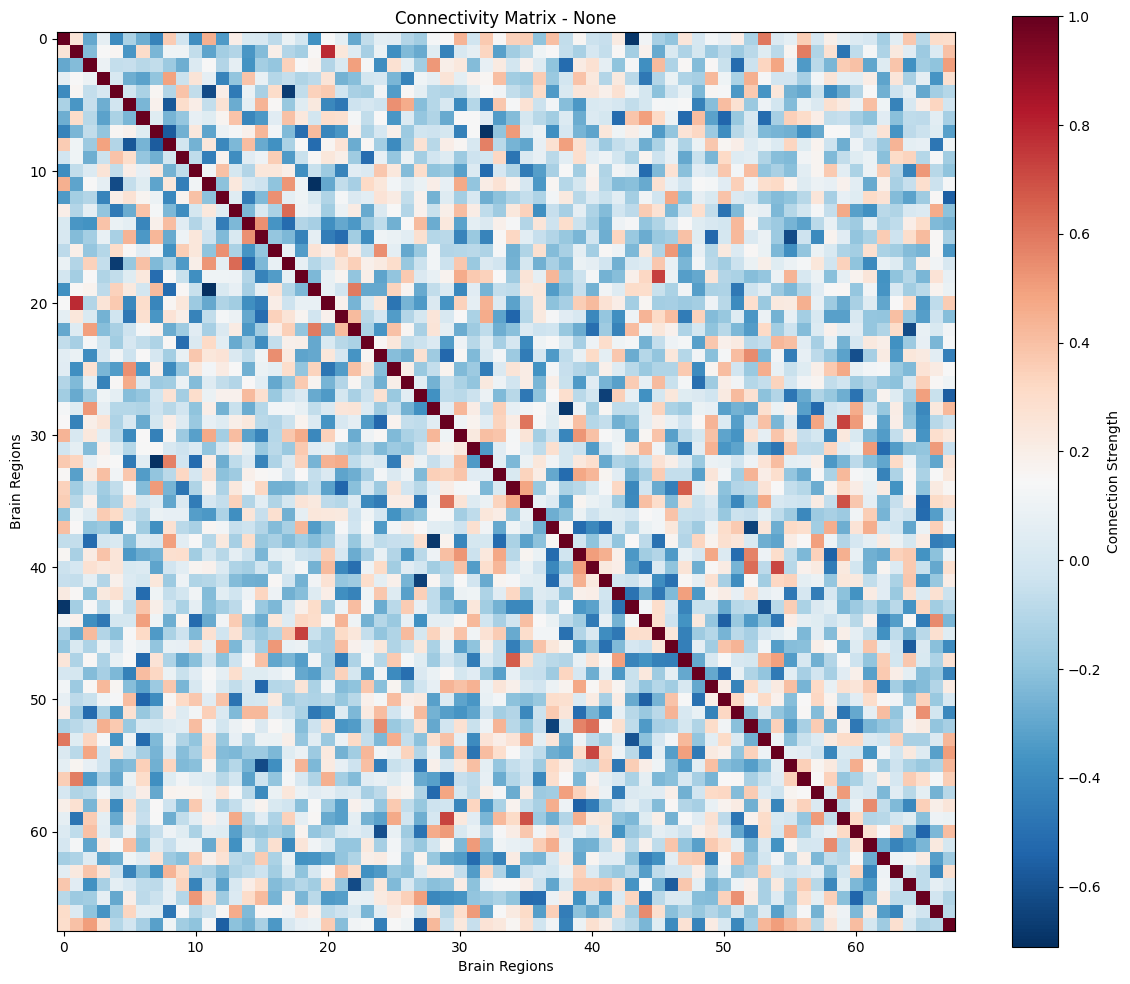

In [7]:
########################### Testing compute_fc_connectome ###########################
import clabtoolkit.parcellationtools as cltparc
import clabtoolkit.imagetools as cltimg

import os
import pandas as pd

fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

# Simulate a time series data
sim_image = '/tmp/simulated_4d_data.nii.gz'
sim_img = cltimg.simulate_image(
    input_image=parc_file,      # Changed from 'input_data'
    simulated_image=sim_image,  # Changed from 'simulated_data'
    n_volumes=20
)

# Example 1: Compute functional connectivity matrix from file and removing the first 3 volumes and keeping only cortical regions
print("")
print('Test 1: Computing functional connectivity matrix from file...')
conn_mat = parc.compute_fc_matrix(sim_image, ts_method="clabtoolkit", vols_to_delete="0-2", roi_names="ctx")
conn_mat.plot_matrix()

<a id="parcellation-compute_structural_connectome"></a>

* 🔹 1.1.4.b. **`compute_structural_connectome`**: Compute a structural connectivity matrix from a tractogram

---

In [ ]:
############################## Testing compute_sc_connectome ###########################
import clabtoolkit.parcellationtools as cltparc
import os
from itables import show
import clabtoolkit.imagetools as cltmimg

fs_home = '/opt/freesurfer'
fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)


<a id="surface-class"></a>

* **🔸 1.2. [`Surface`](#surface-class)**: Class for handling cortical surface data

---
<a id="surface-load_scalar_map"></a>

* 🔹 1.2.1. **`load_scalar_map`**: Load a scalar map onto the surface

---

<a id="surface-load_annotation"></a>

* 🔹 1.2.2. **`load_annotation`**: Load a surface annotation file

---

<a id="surface-map_volume_to_surface"></a>

* 🔹 1.2.3. **`map_volume_to_surface`**: Map a volumetric image onto the surface mesh

---

<a id="tractogram-class"></a>

* **🔸 1.3. [`Tractogram`](#tractogram-class)**: Class for handling white-matter tractography data

---
<a id="tractogram-compute_centroids"></a>

* 🔹 1.3.1. **`compute_centroids`**: Compute the centroid streamline for each bundle

---

In [ ]:
# TODO: Example for Parcellation.compute_structural_connectome()

<a id="tractogram-interpolate_on_tractogram"></a>

* 🔹 1.3.2. **`interpolate_on_tractogram`**: Interpolate scalar values along streamlines

---

<a id="tractogram-filter_streamlines"></a>

* 🔹 1.3.3. **`filter_streamlines`**: Filter streamlines by length, ROI mask, or label

---

In [ ]:
# TODO: Example for Surface.load_scalar_map()

<a id="connectome-class"></a>

* **🔸 1.4. [`Connectome`](#connectome-class)**: Class for storing and analysing connectivity matrices

---
<a id="connectome-get_connectivity_stats"></a>

* 🔹 1.4.1. **`get_connectivity_stats`**: Compute summary statistics from the connectivity matrix

---

In [ ]:
# TODO: Example for Surface.load_annotation()

<a id="connectome-plot_matrix"></a>

* 🔹 1.4.2. **`plot_matrix`**: Render the connectivity matrix as an annotated heatmap

---

In [ ]:
# TODO: Example for Surface.map_volume_to_surface()

<a id="morpho-morphometry"></a>

* **🔷 2. [`Morphometry`](#morpho-morphometry)**: Parse FreeSurfer outputs and compute region-level morphometric values

---
<a id="morpho-freesmorpho"></a>

* **🔸 2.1. [`Parse FreeSurfer Outputs`](#morpho-freesmorpho)**: Utilities for reading FreeSurfer cortical statistics

---
<a id="morpho-parse_freesurfer_cortex_stats"></a>

* 🔹 2.1.1. **`parse_freesurfer_cortex_stats`**: Parse FreeSurfer cortical statistics files into a structured table

---

<a id="parcellation-obasedmorpho"></a>

* **🔸 2.2. [`Object-Based Morphometry`](#parcellation-obasedmorpho)**: Compute region-wise morphometric values from annotation files

---
<a id="morpho-compute_reg_val_fromannot"></a>

* 🔹 2.2.1. **`compute_reg_val_fromannot`**: Compute region-wise values (e.g. thickness, area) from an annotation file

---

In [ ]:
# TODO: Example for Tractogram.compute_centroids()

<a id="parcellation-visualization"></a>

* **🔷 3. [`Visualization`](#parcellation-visualization)**: Plotting neuroimaging objects and composing 3-D scenes

---
<a id="parcellation-pobjects"></a>

* **🔸 3.1. [`Plotting Objects`](#parcellation-pobjects)**: Configure and render individual brain objects

---

In [ ]:
# TODO: Example for Tractogram.interpolate_on_tractogram()

<a id="parcellation-pscene"></a>

* **🔸 3.2. [`Plotting Scene`](#parcellation-pscene)**: Compose and export multi-object brain scenes

---

In [ ]:
# TODO: Example for Tractogram.filter_streamlines()

In [ ]:
# TODO: Example for Connectome.get_connectivity_stats()

In [ ]:
# TODO: Example for Connectome.plot_matrix()

In [ ]:
# TODO: Example for parse_freesurfer_cortex_stats()

In [ ]:
# TODO: Example for compute_reg_val_fromannot()

In [ ]:
# TODO: Examples for plotting individual neuroimaging objects

In [ ]:
# TODO: Examples for composing multi-object PyVista scenes